# Statistics for Bertha
This notebook includes all the code used and graphs made for the project involving plotting the astrometric coordinates of asteroids within 2.5 AU over the Harvard CFA digitalized photographic plates (Dach project).

We use the example of the asteroid Bertha.

In [1]:
import json
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np


In [2]:
with open("observability.json", "r") as f:
    data = json.load(f)

FileNotFoundError: [Errno 2] No such file or directory: 'observability.json'

In [ ]:
mpcnum = '154'
print(len(data[mpcnum]),"entries found")
data[mpcnum]

5649 entries found


[[2447861.7, 'dnb06704', 58.585900499641745, 35.20754230862338],
 [2447825.801388889, 'dnb06693', 67.09771667502281, 33.205797514115154],
 [2447797.7645833334, 'dnb06678', 69.10341465543844, 30.430811855273916],
 [2447440.7590277777, 'dnb06353', 9.524622092572718, -12.96966305348169],
 [2447408.1381944446, 'dsb02688', 15.91835593601175, -11.859334357025704],
 [2447119.918055556, 'dsb02430', 308.3509760701082, -38.47080699866176],
 [2447114.904861111, 'dsb02408', 306.84119891535255, -39.18135237667088],
 [2447088.9381944444, 'dsb02394', 300.10798700779907, -42.781932463230724],
 [2447088.871527778, 'dsb02391', 300.0936797044951, -42.79100670468039],
 [2447083.945138889, 'dsb02382', 299.08884632482227, -43.4586370541163],
 [2447083.9006944443, 'dsb02380', 299.0802665754652, -43.46463270056535],
 [2447062.918055556, 'dsb02365', 296.16218735190876, -46.21758644867347],
 [2447030.9916666667, 'dsb02354', 297.27900996558657, -49.60540022068989],
 [2447026.982638889, 'dsb02347', 297.9491595483

In [ ]:
print(data.keys())
lst=[]
for i in data.keys():
    lst.append(i) #Looking at the data keys for curiosity

dict_keys(['1', '10', '100', '1000', '10007', '1001', '1002', '10020', '10025', '1003', '1004', '10043', '10048', '1005', '1006', '10063', '10064', '10069', '1007', '1008', '10080', '10085', '10094', '10095', '10096', '101', '1010', '10109', '1011', '10111', '10112', '10113', '10114', '10116', '1012', '1013', '1014', '10141', '10142', '10143', '10148', '1015', '1016', '10164', '1017', '1018', '1019', '10195', '102', '1020', '1021', '10217', '1022', '10225', '10227', '1023', '10234', '10235', '10239', '1024', '1025', '10258', '10259', '1026', '10262', '10265', '10269', '1027', '1028', '1029', '10291', '10293', '10296', '103', '1030', '10306', '1031', '10314', '10316', '1032', '1033', '10331', '10337', '1034', '1035', '10351', '10353', '1036', '10379', '1038', '10385', '10386', '10388', '1039', '104', '1040', '10406', '1041', '10410', '10412', '10415', '1042', '10422', '10426', '1043', '1044', '10451', '1046', '10465', '1047', '10478', '1048', '10487', '10489', '1049', '10490', '10492', 

## Plotting Bertha across the ecliptical plane

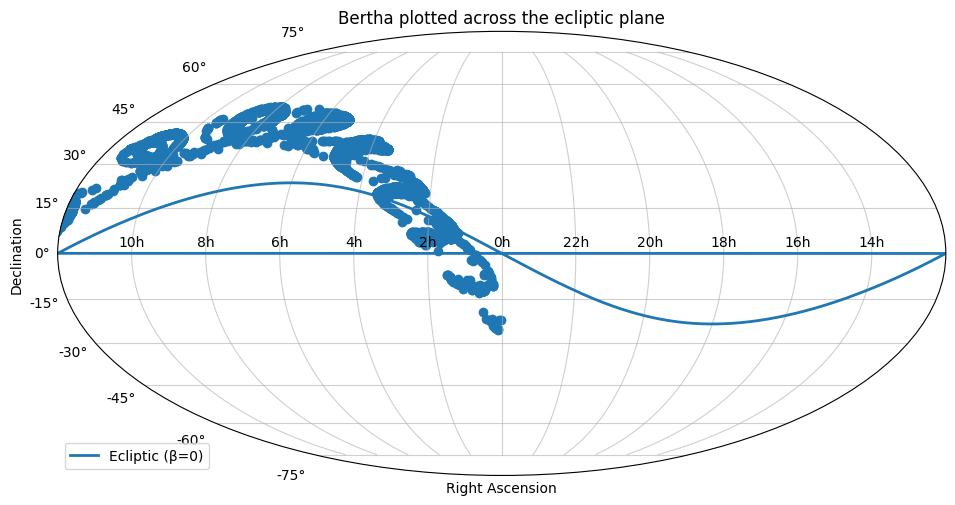

[ 0.00000000e+00  1.44153815e-03  2.88307742e-03 ... -2.88307742e-03
 -1.44153815e-03 -2.24718313e-16] [ 0.00000000e+00  6.24982645e-04  1.24996399e-03 ... -1.24996399e-03
 -6.24982645e-04 -9.74272606e-17]


In [ ]:
mpcnum = '154'

data_array = data[mpcnum]
data_array = np.array(data[mpcnum]).astype(object)
ras= data_array[:,2].astype(float)
decs = data_array[:,3].astype(float)

# --- Ecliptic (β=0) -> Equatorial (RA, Dec) using mean obliquity ---
eps_deg = 23.43928  # obliquity of the ecliptic (deg), good enough for plotting
eps = np.deg2rad(eps_deg)

lam = np.linspace(0, 2*np.pi, 4000)  # ecliptic longitude λ
# For β=0:
dec = np.arcsin(np.sin(eps) * np.sin(lam))
ra  = np.arctan2(np.sin(lam) * np.cos(eps), np.cos(lam))  # range [-pi, pi]

# Convert RA so it increases to the left (astronomy convention)
x = -ra  # flip so RA increases to the left

# --- Plot ---
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection="mollweide")

ax.plot(x, dec, lw=2, label="Ecliptic (β=0)")

xticks = np.deg2rad(np.array([-150, -120, -90, -60, -30, 0, 30, 60, 90, 120, 150]))
# Because we flipped x = -ra, these correspond to RA labels reversed:
# Standard choice: show 10h, 8h, ..., 14h etc. A common, clear set:
ax.set_xticks(xticks)
ax.set_xticklabels(["10h","8h","6h","4h","2h","0h","22h","20h","18h","16h","14h"])

ax.grid(True, alpha=0.6)
ax.set_xlabel("Right Ascension")
ax.set_ylabel("Declination")
ax.legend(loc="lower left")
plt.tight_layout()
plt.scatter(- np.deg2rad(ras), np.deg2rad(decs))
plt.title("Bertha plotted across the ecliptic plane")
plt.savefig("Ecliptic_plane_image.jpg", dpi=600)
plt.show()

print(ra, dec)


# Number of total apperances of the asteroids across all the plates:
Has a really interetsing shape, definitely worth observing it for future studty

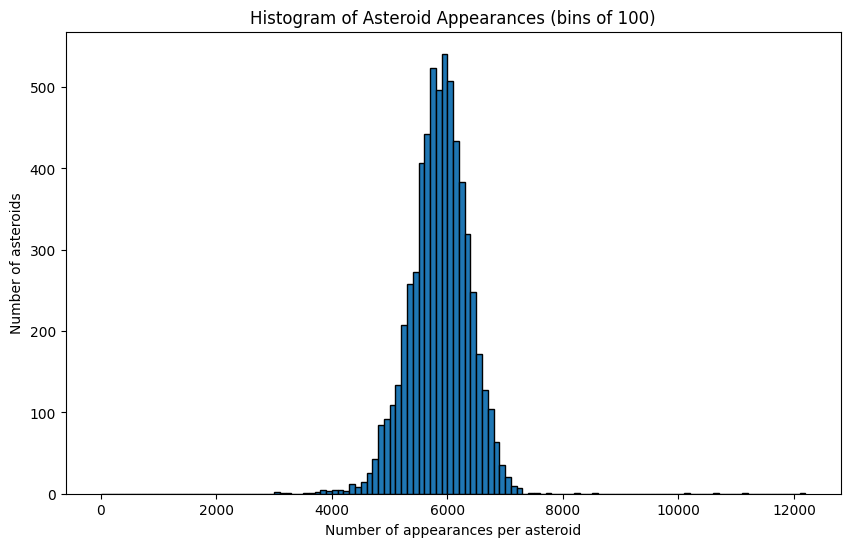

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

asteroid_counts = []

# Looping over all asteroids in the data
for mpcnum in data:
    # Extracting plate IDs (2nd column, index 1)
    plates = [row[1] for row in data[mpcnum] if len(row) > 1]
    
    # Counting unique appearances per plate for this asteroid
    counts = Counter(plates)
    
    # Summing total appearances across plates
    total_appearances = sum(counts.values())
    
    asteroid_counts.append(total_appearances)

# Create bins (adjust step if needed)
max_count = max(asteroid_counts)
bins = np.arange(0, max_count + 100, 100)  # bins of 100 appearances, for convenience

# Plot histogram
plt.figure(figsize=(10,6))
plt.hist(asteroid_counts, bins=bins, edgecolor='black')
plt.xlabel("Number of appearances per asteroid")
plt.ylabel("Number of asteroids")
plt.title("Histogram of Asteroid Appearances (bins of 100)")
plt.savefig("Asteroid_Appearances_across_all_plates.png", dpi=600)
plt.show()



## Observation time of Bertha across the Dasch timespan

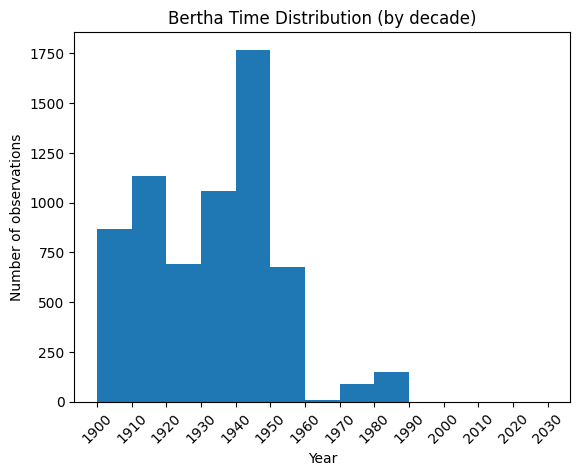

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np
# Extract Julian Dates

julian_dates = [row[0] for row in data[mpcnum]]
julian_dates = [float(row[0]) for row in data[mpcnum]]

# Convert JD to year
years = [1 + (jd - 1721425.5) / 365.25 for jd in julian_dates] 
years = [y for y in years if 1900 <= y <= 2030]

# Decade bins
bins = np.arange(1900, 2040, 10) # Approximate timespan the photographic plates cover

# Plot histogram
plt.hist(years, bins=bins)
plt.xlabel("Year")
plt.ylabel("Number of observations")
plt.title("Bertha Time Distribution (by decade)")
plt.xticks(bins, rotation=45)
plt.savefig("Time_distribution_Bertha.png", dpi=600)
plt.show()


## Observation time of all asteroids across the Dasch timespan:
This includes all asteroids and it has a similar shape to the distribution of only Bertha.

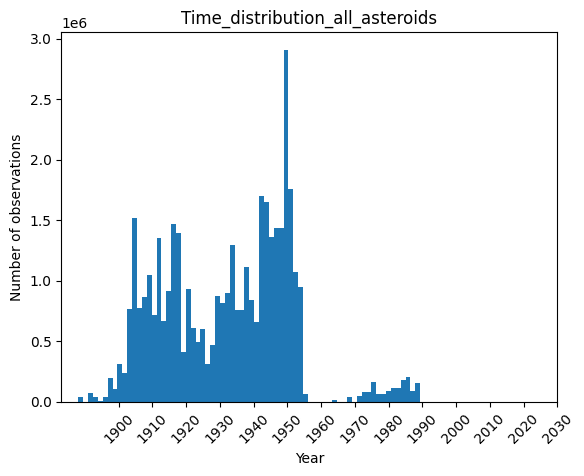

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np
# Extract Julian Dates
full_list=[]

for mpcnum in lst:
    julian_dates = [row[0] for row in data[mpcnum]]
    julian_dates = [float(row[0]) for row in data[mpcnum]]

    # Convert JD to year
    years = [1 + (jd - 1721425.5) / 365.25 for jd in julian_dates]

    # Decade bins
    bins = np.arange(1900, 2040, 10)

    full_list.append(years)


flat = [x for sub in full_list for x in years] # Flattening the list that contains the dates





# Plot histogram
plt.hist(flat, bins=70)
plt.xlabel("Year")
plt.ylabel("Number of observations")
plt.title("Time_distribution_all_asteroids")
plt.xticks(bins, rotation=45)
plt.savefig("Image1.png", dpi=600)
plt.show()
